In [ ]:
import os
import numpy as np
import rasterio
import xarray as xr

In [ ]:
xdata = xr.open_dataset('unprocessed_data/WEATHER/ST2020IA0004_Soybean.nc')
xdata['data'].isel(band=0, time=0).plot()

In [ ]:
with rasterio.open('unprocessed_data/yield_geotiffs/ST2019IA0007_Soybean.tif') as dataset:
    # Get the shape (height, width) and number of bands
    height, width = dataset.shape
    bands = dataset.count
    print(dataset.shape)

    

In [ ]:
np.load('unprocessed_data/S1GRD/ST2024IA0008_Soybean.tif',allow_pickle=True)

In [ ]:
test = np.load('unprocessed_data/WEATHER/ST2019IA0007_Soybean.npy')
test.shape

In [ ]:
root_dir = 'processed_data_monthly'
shapes = set()
dtypes = dict()  # dtype: sample file
dtype_folders = dict()  # dtype: set of subfolders

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            try:
                arr = np.load(file_path, mmap_mode='r')
                # Only keep the last two dimensions
                shape = arr.shape[-2:] if len(arr.shape) >= 2 else arr.shape
                shapes.add(shape)
                if arr.dtype not in dtypes:
                    dtypes[arr.dtype] = file_path
                # Track subfolders for each dtype
                dtype_folders.setdefault(arr.dtype, set()).add(os.path.relpath(subdir, root_dir))
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

print("Unique (-1, -2) shapes in processed_data_monthly:")
for s in sorted(shapes):
    print(s)

print("\nUnique data types in processed_data_monthly (with a sample file):")
for dtype, sample_file in dtypes.items():
    print(f"{dtype}: {sample_file}")

print("\nSubfolders containing each unique dtype:")
for dtype, folders in dtype_folders.items():
    print(f"{dtype}:")
    for folder in sorted(folders):
        print(f"  {folder}")

In [ ]:
root_dir = 'processed_data_monthly'
target_folders = ['MODIS', 'S2L2A']

for folder in target_folders:
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Folder not found: {folder_path}")
        continue
    for file in os.listdir(folder_path):
        if file.endswith('.npy'):
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                if arr.dtype != np.float32:
                    arr = arr.astype(np.float32)
                    np.save(file_path, arr)
                    print(f"Converted and saved: {file_path}")
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

In [ ]:
test = np.load('processed_data_monthly/S2L2A/ST2019IA0007_Soybean.npy')
test.shape

In [ ]:
root_dir = './data_download/S1/final_s1'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
root_dir = './processed_data_biweekly_12/yield_geotiffs'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
import geopandas as gpd
import alphashape
from shapely.geometry import MultiPoint

# Read points
gdf = gpd.read_parquet('Yield_2020_filtered.parquet')

# Only set a CRS if it's missing
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326", allow_override=True)

# Drop rows with missing geometry
gdf = gdf.dropna(subset=["geometry"]).copy()

# Compute alphashape per Layer_ID for tighter boundaries
# alpha=0 gives convex hull, larger values give tighter fit
# Start with alpha=2.0, adjust as needed
def compute_alphashape(points_series, alpha=5.0):
    """Compute alphashape from a series of point geometries."""
    try:
        # Extract coordinates from point geometries
        coords = [(pt.x, pt.y) for pt in points_series]
        if len(coords) < 4:
            # For very few points, fall back to convex hull
            return MultiPoint(coords).convex_hull
        # Compute alphashape
        return alphashape.alphashape(coords, alpha)
    except Exception as e:
        # Fallback to convex hull on error
        return points_series.unary_union.convex_hull

# Apply alphashape per Layer_ID
geom = gdf.groupby("Layer_ID")["geometry"].agg(compute_alphashape)

hull_df = geom.reset_index(name="geometry")
hull_gdf = gpd.GeoDataFrame(hull_df, geometry="geometry")

# Set CRS to match source
hull_gdf = hull_gdf.set_crs(gdf.crs, allow_override=True)

hull_gdf.head()

In [ ]:
gdf.crs

In [ ]:
import matplotlib.pyplot as plt
# Select a specific Polygon (e.g., the first one)
selected_polygon = hull_gdf[hull_gdf['Layer_ID']=='ST2020IA0076'].geometry

# Create a Matplotlib figure and axes
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Plot the selected Polygon on the axes
selected_polygon.plot(ax=ax, color='blue', edgecolor='black')

# Set plot title and labels (optional)
ax.set_title("Visualization of a Single Polygon")
ax.set_xlabel("X-coordinate")
ax.set_ylabel("Y-coordinate")

# Display the plot
plt.show()

Subfolders: ['WEATHER', 'SOIL', 'yield_geotiffs', 'DEM', 'CDL', 'S1GRD', 'S2L2A']
WEATHER: processed_data_biweekly_12/WEATHER/ST2021IANE036_Soybean.npy, shape=(12, 7, 224, 224), dtype=float32


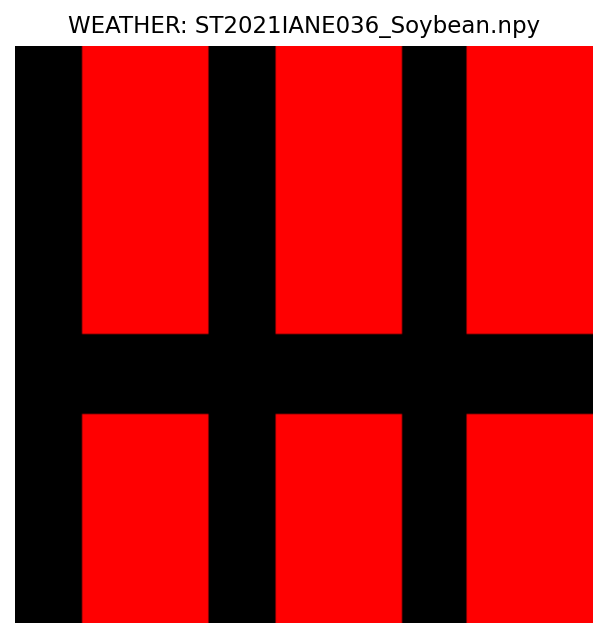

SOIL: processed_data_biweekly_12/SOIL/ST2021IANE036_Soybean.npy, shape=(12, 10, 224, 224), dtype=float32


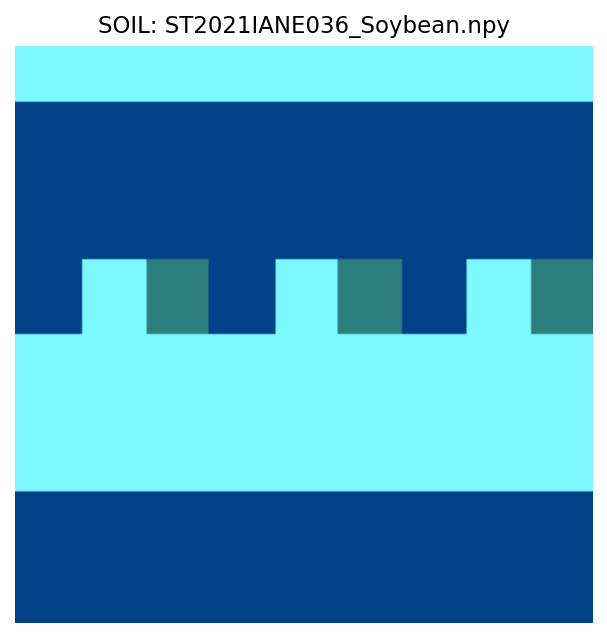

yield_geotiffs: processed_data_biweekly_12/yield_geotiffs/ST2021IANE036_Soybean.npy, shape=(1, 224, 224), dtype=float32


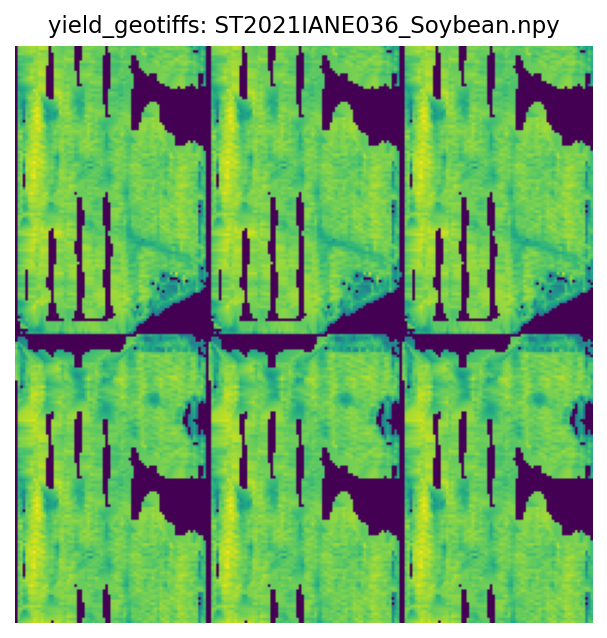

DEM: processed_data_biweekly_12/DEM/ST2021IANE036_Soybean.npy, shape=(12, 1, 224, 224), dtype=float32


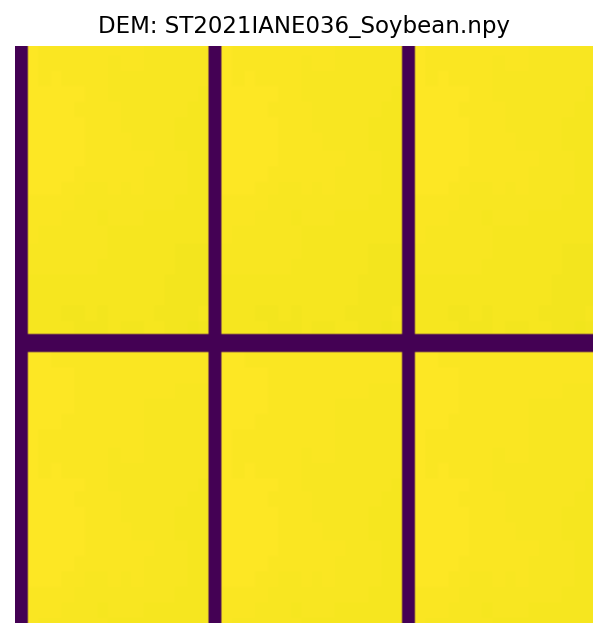

CDL: processed_data_biweekly_12/CDL/ST2021IANE036_Soybean.npy, shape=(12, 1, 224, 224), dtype=float32


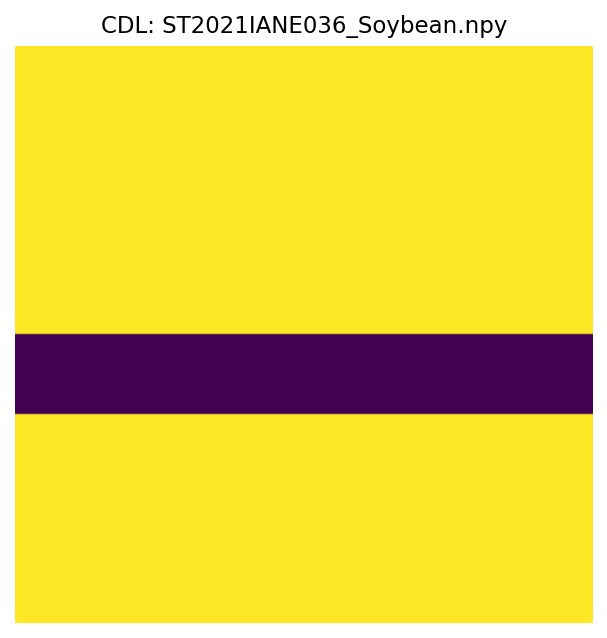

S1GRD: processed_data_biweekly_12/S1GRD/ST2021IANE036_Soybean.npy, shape=(12, 2, 224, 224), dtype=float32


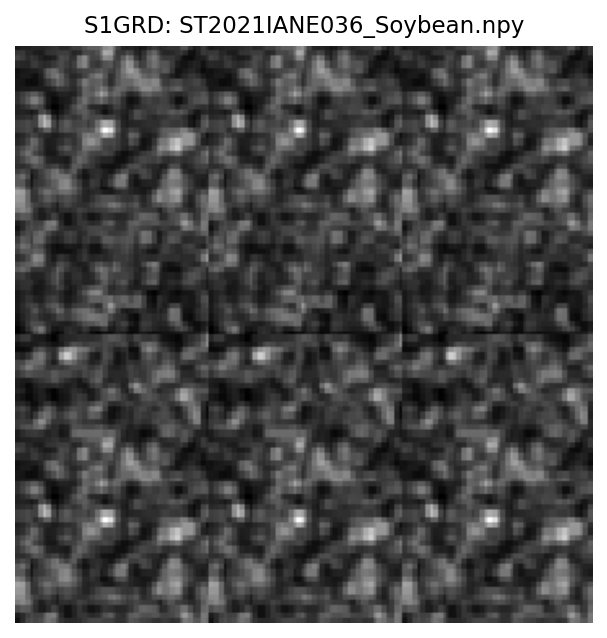

S2L2A: processed_data_biweekly_12/S2L2A/ST2021IANE036_Soybean.npy, shape=(12, 12, 224, 224), dtype=float32


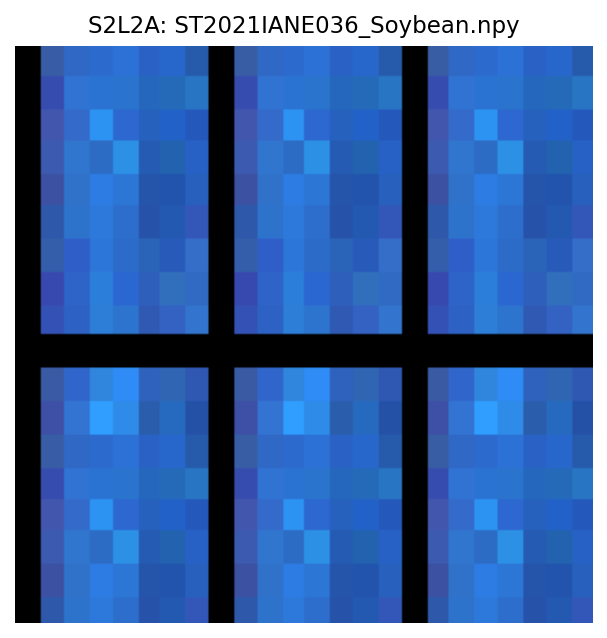

In [39]:
# Visualize a file from each subfolder in processed_data_biweekly_12
import os
import numpy as np
import matplotlib.pyplot as plt

root_dir = "processed_data_biweekly_12"
subfolders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
print("Subfolders:", subfolders)
sub_path = os.path.join(root_dir, subfolders[0])
# file_name = 'ST2023IA0189_Corn.npy'  # Example file name present in all subfolders
file_name = [f for f in os.listdir(sub_path) if f.lower().endswith('.npy')][550]
for sub in subfolders:
    file_path = os.path.join(root_dir, sub, file_name)
    arr = np.load(file_path)
    print(f"{sub}: {file_path}, shape={arr.shape}, dtype={arr.dtype}")
    # Handle shape: (T, C, H, W) or (C, H, W)
    if arr.ndim == 4:
        # Visualize first time step
        img = arr[7]
    elif arr.ndim == 3:
        img = arr
    else:
        print(f"Skipping {file_path}: unexpected shape {arr.shape}")
        continue

    # Use first 3 channels if more
    if img.shape[0] > 3:
        img = img[:3]
    elif img.shape[0] == 2:
        img = np.concatenate([img[:1], img[:1], img[:1]], axis=0)
    # Transpose to H, W, C for matplotlib
    img = np.moveaxis(img, 0, -1)
    # Normalize for visualization
    img_min, img_max = np.nanmin(img), np.nanmax(img)
    if img_max > img_min:
        img_vis = (img - img_min) / (img_max - img_min)
    else:
        img_vis = img

    plt.figure(figsize=(5, 5))
    plt.imshow(img_vis)
    plt.title(f"{sub}: {file_name}")
    plt.axis('off')
    plt.show()

In [ ]:
root_dir = './processed_data_biweekly_12/S1GRD'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.npy')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                arr = np.load(file_path)
                height, width = arr.shape[-2], arr.shape[-1]
                bands = arr.shape[1] if len(arr.shape) > 2 else 1
                print(f"File: {file_path}")
                print(f"Shape: (height={height}, width={width}, bands={bands})")
                print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [6]:
# Create boundary around zero-valued pixels and zero out everything outside
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import binary_fill_holes, binary_dilation
from skimage import morphology

def create_zero_boundary_mask(img_array, tolerance=1e-6):
    """
    Create a mask that connects all zero-valued pixels and fills the interior.
    
    Args:
        img_array: Input array (2D or multi-channel)
        tolerance: Values below this threshold are considered zero
    
    Returns:
        mask: Binary mask where True indicates pixels to keep
    """
    # Handle multi-channel images - check if ANY channel is zero
    if img_array.ndim > 2:
        # Check if all channels are zero at a pixel location
        zero_mask = np.all(np.abs(img_array) <= tolerance, axis=0)
    else:
        zero_mask = np.abs(img_array) <= tolerance
    
    # Invert: True where pixels are NON-zero (valid data)
    valid_data_mask = ~zero_mask
    
    # Fill holes in the valid data region to create a connected boundary
    filled_mask = binary_fill_holes(valid_data_mask)
    
    # Optional: Apply morphological closing to smooth the boundary
    # This connects nearby regions
    struct = morphology.disk(3)  # You can adjust the size
    filled_mask = ndimage.binary_closing(filled_mask, structure=struct)
    filled_mask = binary_fill_holes(filled_mask)
    
    return filled_mask

def apply_boundary_mask(img_array, mask):
    """
    Apply the boundary mask to zero out pixels outside the boundary.
    
    Args:
        img_array: Input array
        mask: Binary mask (True = keep, False = zero out)
    
    Returns:
        masked_array: Array with values outside mask set to zero
    """
    masked_array = img_array.copy()
    
    if img_array.ndim > 2:
        # Apply mask to all channels
        for i in range(img_array.shape[0]):
            masked_array[i][~mask] = 0
    else:
        masked_array[~mask] = 0
    
    return masked_array

In [ ]:
import os

folder_path = 'processed_data_biweekly_12/S1GRD'

soybean_count = 0
corn_count = 0

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            if 'soybean' in file.lower():
                soybean_count += 1
            if 'corn' in file.lower():
                corn_count += 1
    
    print(f"Number of Soybean files: {soybean_count}")
    print(f"Number of Corn files: {corn_count}")
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

folder_path = 'processed_data_biweekly_12/S1GRD'

# Dictionary to store counts: {year: {crop: [counts of all-zero time steps per file]}}
data_by_year_crop = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            # Extract year and crop from filename using regex
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue
            
            year = match.group(1)
            crop = match.group(2).capitalize()
            
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape
                
                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1
                
                # Store the count
                if year not in data_by_year_crop:
                    data_by_year_crop[year] = {}
                if crop not in data_by_year_crop[year]:
                    data_by_year_crop[year][crop] = []
                
                data_by_year_crop[year][crop].append(all_zero_count)
                    
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    # Create visualizations
    years = sorted(data_by_year_crop.keys())
    crops = ['Corn', 'Soybean']
    
    # Plot 1: Distribution by year and crop
    fig, axes = plt.subplots(len(years), 2, figsize=(14, 4*len(years)))
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    for i, year in enumerate(years):
        for j, crop in enumerate(crops):
            ax = axes[i, j]
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                ax.hist(counts, bins=range(0, 14), edgecolor='black', alpha=0.7, align='left')
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop} (n={len(counts)} files)')
                ax.set_xticks(range(0, 13))
                ax.grid(True, alpha=0.3)
                
                # Add statistics
                mean_zeros = np.mean(counts)
                median_zeros = np.median(counts)
                ax.axvline(mean_zeros, color='r', linestyle='--', label=f'Mean: {mean_zeros:.2f}')
                ax.axvline(median_zeros, color='g', linestyle='--', label=f'Median: {median_zeros:.2f}')
                ax.legend()
            else:
                ax.text(0.5, 0.5, f'No {crop} data for {year}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop}')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    for year in years:
        print(f"\nYear: {year}")
        for crop in crops:
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                print(f"  {crop}:")
                print(f"    Total files: {len(counts)}")
                print(f"    Mean all-zero time steps: {np.mean(counts):.2f}")
                print(f"    Median all-zero time steps: {np.median(counts):.2f}")
                print(f"    Min: {np.min(counts)}, Max: {np.max(counts)}")
                print(f"    Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
                print(f"    Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
            else:
                print(f"  {crop}: No data")
    
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_12/S1GRD'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_12/S2L2A'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")

Soybean: found 357 files (aggregated pixels: 8,947,850)
  Min: -0.00, Max: 149.92
  Mean: 34.39, Median: 40.21
Corn: found 399 files (aggregated pixels: 10,445,842)
  Min: -0.00, Max: 549.43
  Mean: 119.98, Median: 153.80


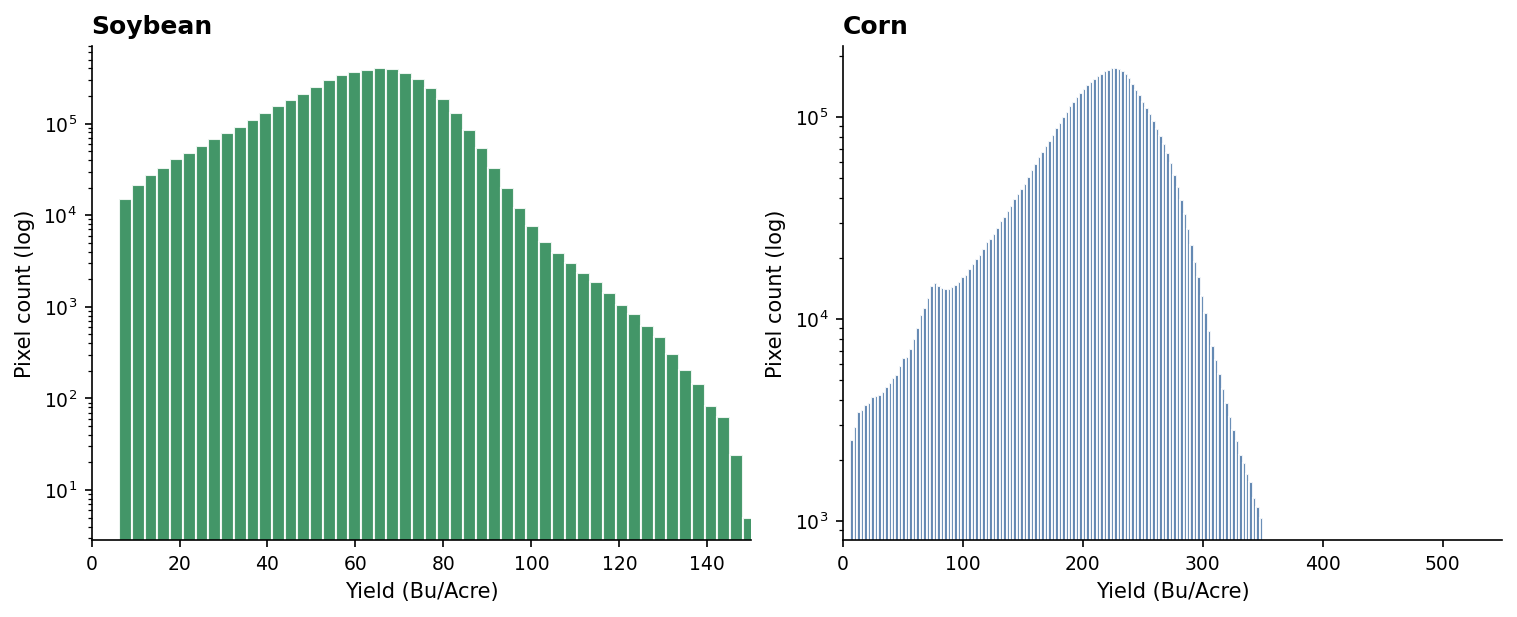

In [21]:
import matplotlib as mpl
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import rasterio
# Paper-ready: read all yield files from unprocessed_data/yield_geotiffs, aggregate pixels by crop, and save high-quality side-by-side plots.
yields_dir = "./unprocessed_data/yield_geotiffs"
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# Aggregate pixel values per crop by reading all files in yield_geotiffs
results = {"Soybean": [], "Corn": []}
file_counts = {"Soybean": 0, "Corn": 0}

for root, _, files in os.walk(yields_dir):
    for file in files:
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            
            # Determine crop from filename
            if 'soybean' in file.lower():
                crop = 'Soybean'
            elif 'corn' in file.lower():
                crop = 'Corn'
            else:
                continue  # Skip files that don't match either crop
            
            file_counts[crop] += 1
            
            try:
                with rasterio.open(file_path) as ds:
                    data = ds.read().astype(np.float32).ravel()
                    if ds.nodata is not None:
                        data = data[data != ds.nodata]
                
                data = data[np.isfinite(data)]
                if data.size:
                    results[crop].append(data)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Convert lists to concatenated arrays
for crop in results:
    if results[crop]:
        results[crop] = np.concatenate(results[crop])
    else:
        results[crop] = np.array([], dtype=np.float32)
    print(f"{crop}: found {file_counts[crop]} files (aggregated pixels: {results[crop].size:,})")
    if results[crop].size > 0:
        print(f"  Min: {np.min(results[crop]):.2f}, Max: {np.max(results[crop]):.2f}")
        print(f"  Mean: {np.mean(results[crop]):.2f}, Median: {np.median(results[crop]):.2f}")

# Paper-style plotting
mpl.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

cmap = {"Soybean": "#2E8B57", "Corn": "#4C78A8"}

# Determine common x range based on 0.1-99.9 percentiles of positive pixels across crops
pos_values = []
for arr in results.values():
    if arr.size:
        pv = arr[arr > 0]
        if pv.size:
            pos_values.append(pv)
if pos_values:
    stacked_pos = np.concatenate(pos_values)
    x_lo = np.percentile(stacked_pos, 0.1)
    x_hi = np.percentile(stacked_pos, 99.9)
    if x_hi <= x_lo:
        x_lo, x_hi = stacked_pos.min(), stacked_pos.max()
else:
    x_lo, x_hi = None, None

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, (crop, data) in zip(axes, results.items()):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if data.size == 0:
        ax.text(0.5, 0.5, "No data found", ha="center", va="center")
        ax.set_title(crop)
        continue

    total = data.size
    zeros = np.sum(data == 0)
    frac_zeros = zeros / total if total else 0.0

    # Positive (non-zero) data for histogram; fall back to full data if no positives
    pos = data[data > 0]
    if pos.size == 0:
        pos = data  # all zeros or all nonpositive

    # bins: linear between chosen range (or data min/max) with 120 bins
    if x_lo is not None and x_hi is not None and x_hi > x_lo:
        bins = np.linspace(x_lo, x_hi, 120)
    else:
        bins = 120

    # plot histogram of positive values
    ax.hist(pos, bins=bins, color=cmap.get(crop, "#333333"), edgecolor="white", alpha=0.9)
    ax.set_yscale("log")
    ax.set_xlabel("Yield (Bu/Acre)")
    ax.set_ylabel("Pixel count (log)")
    # ax.set_title(f"{crop} — pixels={total:,}\nzeros={zeros:,} ({frac_zeros*100:.1f}%)", loc="left")
    ax.set_title(f"{crop}", loc="left", fontweight="bold", fontsize=12)

    # statistics on full data (including zeros)
    pcts = np.percentile(data, [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9])
    mean = np.mean(data)
    med = np.median(data)
    if crop == "Soybean":
        ax.set_xlim(0, 150)
    else:
        ax.set_xlim(0,550)
    # # vertical lines for median and mean (on the positive histogram range)
    # if med > 0:
    #     ax.axvline(med, color="#E45756", linestyle="--", linewidth=1.2, label=f"median={med:.1f}")
    # if mean > 0:
    #     ax.axvline(mean, color="#72B7B2", linestyle=":", linewidth=1.2, label=f"mean={mean:.1f}")
    # ax.legend(frameon=False, loc="upper right")

    # annotate percentiles in a tidy box
    # stats_txt = (
    #     "p0.1={:.1f}\n1%={:.1f}\n5%={:.1f}\n25%={:.1f}\n50%={:.1f}\n75%={:.1f}\n95%={:.1f}\n99%={:.1f}\n99.9%={:.1f}"
    # ).format(*pcts)
    # ax.text(0.98, 0.98, stats_txt, ha="right", va="top", transform=ax.transAxes,
    #         fontsize=8, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    # # set shared x-limits if determined
    # if x_lo is not None and x_hi is not None and x_hi > x_lo:
    #     ax.set_xlim(x_lo, x_hi)

# Save high-quality files
fig.savefig(os.path.join(out_dir, "yield_distributions_side_by_side_all.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "yield_distributions_side_by_side_all.pdf"), bbox_inches="tight")
plt.show()


Soybean: found 357 files (aggregated pixels: 17,912,832)
Corn: found 399 files (aggregated pixels: 20,020,224)


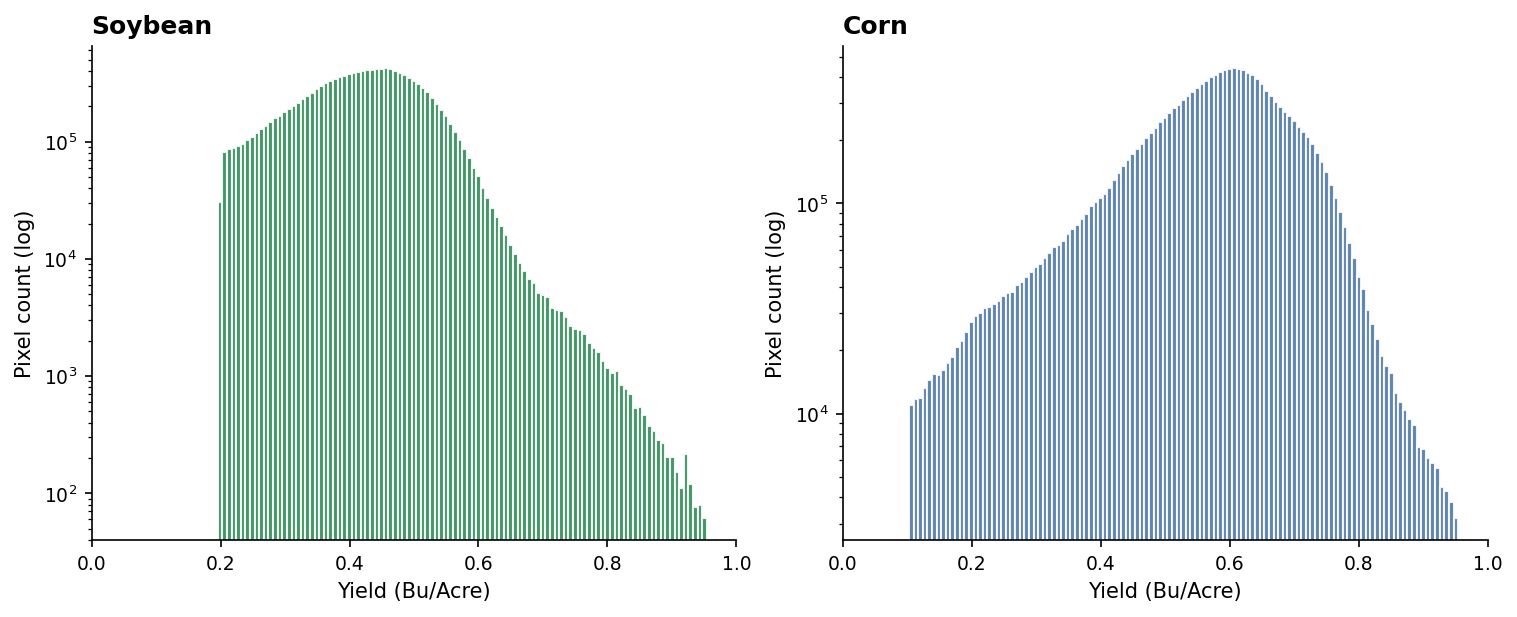

In [22]:
import matplotlib as mpl
import os
import numpy as np
import matplotlib.pyplot as plt
import re
# Paper-ready: read all yield files from yield_geotiffs, aggregate pixels by crop, and save high-quality side-by-side plots.
splits_dir = globals().get("splits_dir", "./processed_data_biweekly_12")
yields_dir = os.path.join(splits_dir, "yield_geotiffs")
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# Aggregate pixel values per crop by reading all files in yield_geotiffs
results = {"Soybean": [], "Corn": []}
file_counts = {"Soybean": 0, "Corn": 0}

for root, _, files in os.walk(yields_dir):
    for file in files:
        if file.lower().endswith(('.tif', '.tiff', '.npy')):
            file_path = os.path.join(root, file)
            
            # Determine crop from filename
            if 'soybean' in file.lower():
                crop = 'Soybean'
            elif 'corn' in file.lower():
                crop = 'Corn'
            else:
                continue  # Skip files that don't match either crop
            
            file_counts[crop] += 1
            
            try:
                if file.lower().endswith(('.tif', '.tiff')):
                    with rasterio.open(file_path) as ds:
                        data = ds.read().astype(np.float32).ravel()
                        if ds.nodata is not None:
                            data = data[data != ds.nodata]
                elif file.lower().endswith('.npy'):
                    data = np.load(file_path).ravel().astype(np.float32)
                
                data = data[np.isfinite(data)]
                if data.size:
                    results[crop].append(data)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Convert lists to concatenated arrays
for crop in results:
    if results[crop]:
        results[crop] = np.concatenate(results[crop])
    else:
        results[crop] = np.array([], dtype=np.float32)
    print(f"{crop}: found {file_counts[crop]} files (aggregated pixels: {results[crop].size:,})")

# Paper-style plotting
mpl.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

cmap = {"Soybean": "#2E8B57", "Corn": "#4C78A8"}

# Determine common x range based on 0.1-99.9 percentiles of positive pixels across crops
pos_values = []
for arr in results.values():
    if arr.size:
        pv = arr[arr > 0]
        if pv.size:
            pos_values.append(pv)
if pos_values:
    stacked_pos = np.concatenate(pos_values)
    x_lo = np.percentile(stacked_pos, 0.1)
    x_hi = np.percentile(stacked_pos, 99.9)
    if x_hi <= x_lo:
        x_lo, x_hi = stacked_pos.min(), stacked_pos.max()
else:
    x_lo, x_hi = None, None

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, (crop, data) in zip(axes, results.items()):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if data.size == 0:
        ax.text(0.5, 0.5, "No data found", ha="center", va="center")
        ax.set_title(crop)
        continue

    total = data.size
    zeros = np.sum(data == 0)
    frac_zeros = zeros / total if total else 0.0

    # Positive (non-zero) data for histogram; fall back to full data if no positives
    pos = data[data > 0]
    if pos.size == 0:
        pos = data  # all zeros or all nonpositive

    # bins: linear between chosen range (or data min/max) with 120 bins
    if x_lo is not None and x_hi is not None and x_hi > x_lo:
        bins = np.linspace(x_lo, x_hi, 120)
    else:
        bins = 120

    # plot histogram of positive values
    ax.hist(pos, bins=bins, color=cmap.get(crop, "#333333"), edgecolor="white", alpha=0.9)
    ax.set_yscale("log")
    ax.set_xlabel("Yield (Bu/Acre)")
    ax.set_ylabel("Pixel count (log)")
    # ax.set_title(f"{crop} — pixels={total:,}\nzeros={zeros:,} ({frac_zeros*100:.1f}%)", loc="left")
    ax.set_title(f"{crop}", loc="left", fontweight="bold", fontsize=12)

    # statistics on full data (including zeros)
    pcts = np.percentile(data, [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9])
    mean = np.mean(data)
    med = np.median(data)
    if crop == "Soybean":
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, 1)
    # # vertical lines for median and mean (on the positive histogram range)
    # if med > 0:
    #     ax.axvline(med, color="#E45756", linestyle="--", linewidth=1.2, label=f"median={med:.1f}")
    # if mean > 0:
    #     ax.axvline(mean, color="#72B7B2", linestyle=":", linewidth=1.2, label=f"mean={mean:.1f}")
    # ax.legend(frameon=False, loc="upper right")

    # annotate percentiles in a tidy box
    # stats_txt = (
    #     "p0.1={:.1f}\n1%={:.1f}\n5%={:.1f}\n25%={:.1f}\n50%={:.1f}\n75%={:.1f}\n95%={:.1f}\n99%={:.1f}\n99.9%={:.1f}"
    # ).format(*pcts)
    # ax.text(0.98, 0.98, stats_txt, ha="right", va="top", transform=ax.transAxes,
    #         fontsize=8, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    # # set shared x-limits if determined
    # if x_lo is not None and x_hi is not None and x_hi > x_lo:
    #     ax.set_xlim(x_lo, x_hi)

# Save high-quality files
fig.savefig(os.path.join(out_dir, "yield_distributions_side_by_side_val.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "yield_distributions_side_by_side_val.pdf"), bbox_inches="tight")
plt.show()